In [124]:
import pandas as pd
import numpy as np

In [87]:
%run src/common_functions.py
%run src/gradient_descent.py

# Review of the parameters of Gradient Descent

We will use $g(x) = (x-3)^2$ as our example function again.

Gradient Descent will approximate $\hat{y}$ using 

$$
\frac{dg}{dx} = 2(x-3)
$$

In [96]:
def g(x: float) -> float:
    """g(x) = (x - 3)^2"""
    return (x-3)**2

def dg(x: float) -> float:
    """Derivate of quadratic function g: dg/dx = 2(x-3)"""
    return 2*(x-3)

### Initial $x$ Value

The initial value of $x$, our starting point, can heavily influence the behavior and outcome of gradient descent, particularly in combination with the learning rate and the maximum number of iterations.

We can see that all gradient descent variants eventually converge towards the minimum at $x=3$. However, depending on the learning rate, initial value and number of iterations, some approaches come arbitrarily close to the minimum, while others remain further away when the algorithm terminates.

Another problem related to the initial value is the global-local minimum dilemma, illustrated in `local_minima.ipynb`. For non-convex functions, choosing an unfavorable starting value can lead gradient descent towards a local minimum instead of the global minimum. In such cases, the starting point can therefore determine which minimum the algorithm converges to.

A function $f: X \rightarrow \R$ is defined as convex if it satifies the chors property

$$
f(t x_1 + (1 - t) x_2) \leq tf(x_1) +  (1- t)f(x_2)
$$

for all $0 \leq t \leq 1$ and $x_1, x_2 \in X$.

Geometrically, this inequality states that any point on a line segment (chord) connecting $(x_1, f(x_1))$ and $(x_2, f(x_2))$ lies on or above the corresponding point on the graph of $f$. In short, a convex function is a function that is open upwards, s.a. $f(x) = x^2$ or $f(x) = e^x$.

For our simple quadratic function, $f(x)=(x-3)^2$, this is not an issue because the function is convex and has only one minimum. However, it becomes an important consideration when applying gradient descent to more complex, non-convex functions.

To summarize, there is no universally optimal initial value that we can choose beforehand. A common choice is to initialize parameters at $0$, but this is simply a convention rather than a guarantee of good convergence. Depending on the function, learning rate and optimization problem, the initial value can have a significant impact on how quickly gradient descent converges and, for non-convex functions, which minimum it reaches.


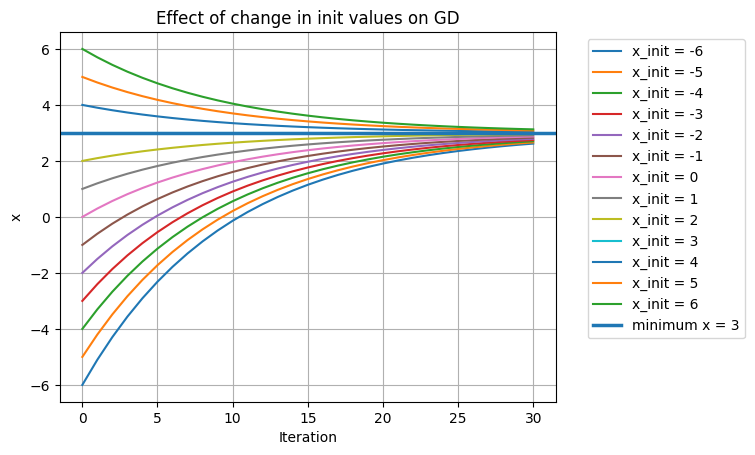

In [97]:
x_init_values = range(-6, 7, 1)
x_histories = [gradient_descent_history(dg, x_init=x_init, learning_rate=0.05, max_iter=30) for x_init in x_init_values]

histories_x_init = {x_init: x_history for x_init, x_history in zip(x_init_values, x_histories)}

plot_parameter_effects(histories_x_init, parameter_name="x_init", title="Effect of change in init values on GD", global_min=3)

### Learning Rates

The learning rate $\eta$ in Gradient Descent heavily influences the step size, as it is multiplied by the computed gradient. Therefore, a smaller learning rate results in smaller parameter updates, whereas a larger learning rate results in larger updates, generally in the direction indicated by the negative gradient.

If the learning rate is too small, Gradient Descent may make only very small updates and therefore fail to reach the desired $x$ with $\frac{df}{dx} = 0$ within the given number of iterations.

Conversely, if the learning rate is too large, Gradient Descent may overshoot the minimum. This can cause the algorithm to oscillate around the minimum or even diverge, with each update moving further away from the optimal value.

Again, these effects can only be compared meaningfully when the number of iterations and the initial $x$ value are held constant.

The table below illustrates the behavior of different learning rates, ranging from $0.0001$ to $10$, for the same function, number of iterations and initial $x$ value.

It becomes apparent that very small learning rates, such as $0.0001$ or $0.001$, do not make sufficiently large updates to reach the optimal value of $x=3$ within only 30 iterations. Learning rates of $0.1$ and $0.5$, on the other hand, appear to work well for this specific problem, as they converge quickly and precisely towards the minimum.

The learning rates of $1$ and $10$ produce more unusual results. To understand why, consider the Gradient Descent update rule:

$$
x_{n+1} = x_n - \eta \frac{df}{dx}(x_n)
$$

For our function

$$
f(x)=(x-3)^2
$$

the derivative is

$$
\frac{df}{dx}=2(x-3).
$$

Therefore, the update becomes

$$
x_{n+1}=x_n-2\eta(x_n-3).
$$

For $\eta=10$, this simplifies to

$$
x_{n+1}=x_n-20(x_n-3).
$$

The problem becomes clear when we look at the distance from the minimum. Let $e_n=x_n-3$ represent the current distance from the minimum. The update $e_{n+1} = x_{n+1} - 3$ becomes

$$
e_{n+1} = x_n - 2\eta (x_n -3) -3 = (x_n - 3) - 2\eta (x_n - 3) = (1 - 2\eta)(x_n - 3) = (1-2\eta)e_n.
$$

With $\eta=10$:

$$
e_{n+1}=-19e_n.
$$

This means that in every iteration, the distance from the minimum is multiplied by $19$ and its sign is reversed. The sign reversal means that the algorithm jumps from one side of the minimum to the other, while multiplying the distance by $19$ means that each jump becomes dramatically larger.

For example, if the current distance from the minimum is $1$, the next distance will be $|-19|$, then $|361|$, then $|-6859|$, and so on. After only 30 iterations, this repeated multiplication produces an astronomically large value, explaining the seemingly nonsensical result of

$$
x=-691399853691585645136528558217799880200.
$$

This is an example of divergence. The learning rate is so large that the algorithm does not move towards the minimum; instead, each update amplifies the previous error.

In conclusion, finding a suitable learning rate is an important part of applying Gradient Descent. There is no universally optimal learning rate, as the appropriate value depends on the function, the scale of the features, the initialization and the optimization problem. 

In general, values between $0.001$ and $0.1$ can work well given a sufficient number of iterations.


In [110]:
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10]
x_hat_values = [gradient_descent_history(dg, x_init=0, learning_rate=learning_rate, max_iter=30) for learning_rate in learning_rates]

learning_rate_df = pd.DataFrame(
    {
        "learning_rate": learning_rates,
        "x_hat": [x_hat[-1] for x_hat in x_hat_values]
    }
).set_index("learning_rate").reset_index()

histories_lr = {lr: x_history for lr, x_history in zip(learning_rates, x_hat_values)}

learning_rate_df

,learning_rate,x_hat
0,0.0001,0.017948
1,0.0010,0.174876
2,0.0100,1.363547
3,0.0500,2.872827
4,0.1000,2.996286
5,0.5000,3.0
6,1.0000,0
7,10.0000,-691399853691585645136528558217799880200


The following plot illustrates oscillation, where the learning rate $\eta=1$ is exactly large enough for the distance $e$ from our minimum $x=3$ to change its sign at every iteration instead of converging towards it.
This becomes clear when substituting $\eta=1$ into

$$
e_{n+1}=(1-2\eta)e_n.
$$

We get

$$
e_{n+1} = (1-2\eta)e_n = (1-2)e_n = -e_n
$$

which means that for the next iteration, we'll get

$$
e_{n+1} = -e_n(1-2\eta)= -e_n(1-2) = e_n
$$

oscillating between the same distance forever, switching signs: $e_0 = 3$, $e_1 = -3$, $e_2 = 3$ $\dots$

Therefore, the algorithm oscillates indefinitely between the two points that are equally distant from the minimum. It neither converges towards $x=3$ nor diverges away from it.

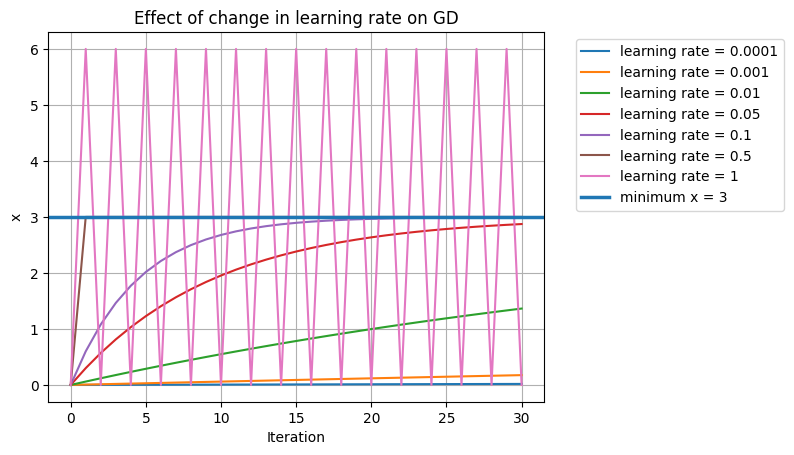

In [111]:
plot_parameter_effects(histories_lr, parameter_name="learning rate", title="Effect of change in learning rate on GD", global_min=3, exempt=(10,))

This next plot makes it even clearer with GD jump from $x=3$ to $x=6$ for $30$ iterations without any progress towards $x=3$.

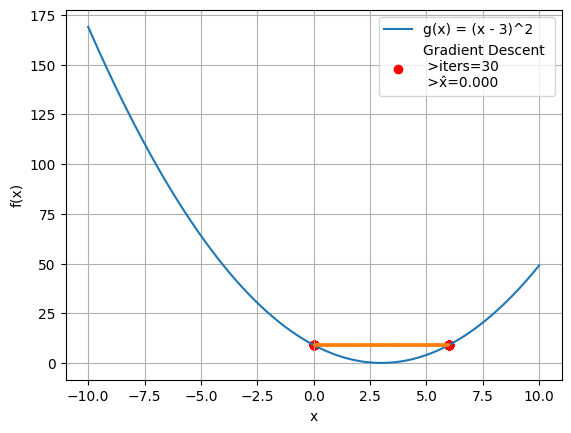

In [112]:
plot_function_and_gd(g, histories_lr[1], x_max=10)

Excluding $\eta = 1$ and $\eta = 10$ from the plot above draws a clearer picture for the other learning rates and their convergance towards the minimum.

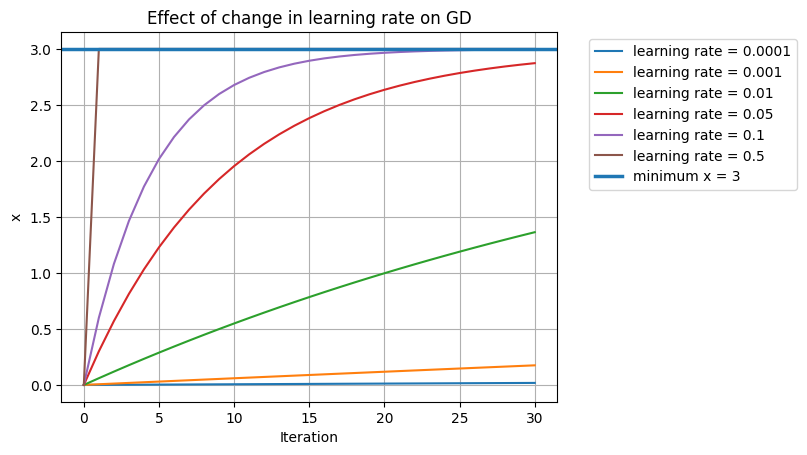

In [103]:
plot_parameter_effects(histories_lr, parameter_name="learning rate", title="Effect of change in learning rate on GD", global_min=3, exempt=(1, 10))

### Stopping Criterion

We can also stop Gradient Descent early if it is no longer improving according to three different stopping criteria. If there is insufficient reason to continue, we can save computational resources while obtaining (nearly) the same result as running all iterations.

All three criteria compare some metric to a tolerance parameter `tol`, which is commonly set to a small value such as $1\times10^{-4}$ to $1\times10^{-8}$.

*1)* Parameter Change

We can calculate the difference in the parameter values by comparing the previous parameter values $x_{i-1}$ to the current values $x_i$. If the update from the previous iteration to the current iteration is sufficiently small, i.e. smaller than the provided `tol` parameter, we can terminate Gradient Descent early.

*2)* Loss Change

If a loss function is provided, as is typically the case in machine learning, we can calculate the loss after each Gradient Descent step using the updated parameters. If the change in loss between the previous and current iteration is smaller than `tol`, we can terminate Gradient Descent early.

*3)* Gradient Norm

A common stopping criterion for Gradient Descent is measuring the magnitude of the gradient. This allows us to answer the question: "Is the slope sufficiently small?"

The magnitude of a matrix can be measured using the Frobenius norm, given by

$$
||A||_F = \sqrt{\sum_{i,j}|a_{i,j}|^2}
$$

The same concept can be applied to vectors and scalar, which our $w$ gradient and $b$ gradient are respectively. Let

$$
\mathbf{g} =
\begin{bmatrix}
-0.42 \\
-0.31 \\
-0.21
\end{bmatrix}
$$

be the gradient vector of the coefficients being approximated by Gradient Descent.

For a vector, the Frobenius norm is equivalent to the Euclidean/ $L_2$ norm:

$$
\|\mathbf{g}\|_2
=
\sqrt{(-0.42)^2+(-0.31)^2+(-0.21)^2}
\approx 0.563
$$



If the resulting gradient magnitude is smaller than the provided tolerance, we can assume that the slope is sufficiently small and halt Gradient Descent early.


In [129]:
max_iter = 500
x_hist_too_many_iters = gradient_descent_history(dg, learning_rate=0.1, max_iter=max_iter)

print(f"Max. x value approximated: {np.max(x_hist_too_many_iters)}")
print(f"Found at index: {(idx := np.argmax(x_hist_too_many_iters))}")
print(f"Iterations without improvements: {max_iter-idx}")

Max. x value approximated: 2.999999999999999
Found at index: 159
Iterations without improvements: 341


In [106]:
iter_range = range(100, 701, 100)
stopping_criteria = ["parameter", "gradient"]

results = []

for sc in stopping_criteria:
    for max_iter in iter_range:
        x_history = gradient_descent_history_sc(
            dg,
            x_init=0,
            learning_rate=0.01,
            max_iter=max_iter,
            tol=1e-4,
            sc=sc
        )

        results.append({
            "stopping_criterion": sc,
            "max_iters": max_iter,
            "true_iters": len(x_history) - 1,
            "x_hat": x_history[-1]
        })

df_stopping_criterion = (
    pd.DataFrame(results)
    .set_index(["stopping_criterion", "max_iters"])
)

df_stopping_criterion

true_iters     x_hat
stopping_criterion max_iters                      
parameter          100               100  2.602141
                   200               200  2.947236
                   300               300  2.993002
                   400               318  2.995136
                   500               318  2.995136
                   600               318  2.995136
                   700               318  2.995136
gradient           100               100  2.602141
                   200               200  2.947236
                   300               300  2.993002
                   400               400  2.999072
                   500               500  2.999877
                   600               546  2.999951
                   700               546  2.999951